In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0, 0.5, 'Y dataset')

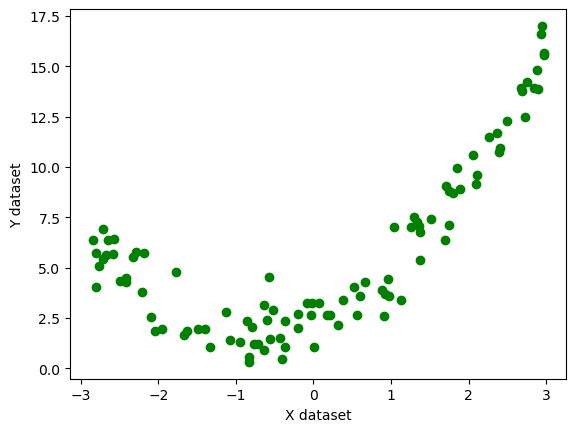

In [2]:
# Quadratic equation used as  y = 0.5 +1.5x + x^2
x =  6 * np.random.rand(100,1) -3 
y = 0.5 +x**2 +1.5*x + 2 + np.random.randn(100,1)
plt.scatter(x,y, color='g')
plt.xlabel("X dataset")
plt.ylabel("Y dataset")

In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state= 42)

In [4]:
## now implement simple linear regresssion
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
from sklearn.metrics import r2_score
score = r2_score(y_test, regression.predict(x_test))
print(score)

0.43428358058233407


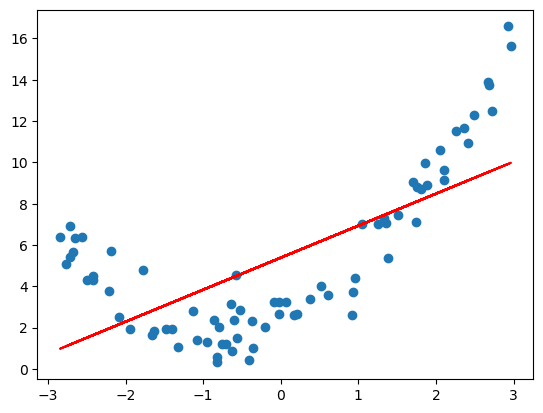

In [6]:
# visualise this model
plt.plot(x_train, regression.predict(x_train), color= 'r')
plt.scatter(x_train, y_train)


This is what the reason for the accuracy 17 %

## Polynomial Transformation

In [7]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree= 2, include_bias= True)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [8]:
x_test_poly

array([[ 1.00000000e+00,  9.68305027e-01,  9.37614624e-01],
       [ 1.00000000e+00, -2.32854645e+00,  5.42212858e+00],
       [ 1.00000000e+00,  2.38972840e+00,  5.71080182e+00],
       [ 1.00000000e+00,  2.74650891e+00,  7.54331118e+00],
       [ 1.00000000e+00,  1.12462954e+00,  1.26479160e+00],
       [ 1.00000000e+00, -4.29949913e-01,  1.84856927e-01],
       [ 1.00000000e+00,  2.95173054e+00,  8.71271319e+00],
       [ 1.00000000e+00,  1.37605654e+00,  1.89353161e+00],
       [ 1.00000000e+00, -2.58609238e+00,  6.68787378e+00],
       [ 1.00000000e+00, -2.80464748e+00,  7.86604748e+00],
       [ 1.00000000e+00,  8.80880188e-01,  7.75949905e-01],
       [ 1.00000000e+00,  1.29201189e+00,  1.66929473e+00],
       [ 1.00000000e+00, -2.28690655e+00,  5.22994159e+00],
       [ 1.00000000e+00,  5.64829008e-01,  3.19031809e-01],
       [ 1.00000000e+00,  6.66454938e-01,  4.44162184e-01],
       [ 1.00000000e+00,  2.89766644e+00,  8.39647079e+00],
       [ 1.00000000e+00,  2.87780451e+00

In [9]:
x_test_poly

array([[ 1.00000000e+00,  9.68305027e-01,  9.37614624e-01],
       [ 1.00000000e+00, -2.32854645e+00,  5.42212858e+00],
       [ 1.00000000e+00,  2.38972840e+00,  5.71080182e+00],
       [ 1.00000000e+00,  2.74650891e+00,  7.54331118e+00],
       [ 1.00000000e+00,  1.12462954e+00,  1.26479160e+00],
       [ 1.00000000e+00, -4.29949913e-01,  1.84856927e-01],
       [ 1.00000000e+00,  2.95173054e+00,  8.71271319e+00],
       [ 1.00000000e+00,  1.37605654e+00,  1.89353161e+00],
       [ 1.00000000e+00, -2.58609238e+00,  6.68787378e+00],
       [ 1.00000000e+00, -2.80464748e+00,  7.86604748e+00],
       [ 1.00000000e+00,  8.80880188e-01,  7.75949905e-01],
       [ 1.00000000e+00,  1.29201189e+00,  1.66929473e+00],
       [ 1.00000000e+00, -2.28690655e+00,  5.22994159e+00],
       [ 1.00000000e+00,  5.64829008e-01,  3.19031809e-01],
       [ 1.00000000e+00,  6.66454938e-01,  4.44162184e-01],
       [ 1.00000000e+00,  2.89766644e+00,  8.39647079e+00],
       [ 1.00000000e+00,  2.87780451e+00

In [10]:
regression.fit(x_train_poly, y_train)
y_pred = regression.predict(x_test_poly)
score2 = r2_score(y_test, y_pred)
print(score2)

0.9460685220640132


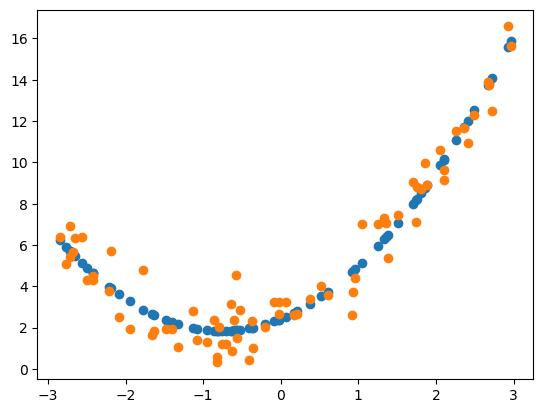

In [11]:
plt.scatter(x_train, regression.predict(x_train_poly))
plt.scatter(x_train, y_train)

In [12]:
poly = PolynomialFeatures(degree= 3, include_bias= True)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [13]:
regression.fit(x_train_poly, y_train)
y_pred = regression.predict(x_test_poly)
score2 = r2_score(y_test, y_pred)
print(score2)

0.942554942061095


#### Prediction of new dataset

In [14]:
x_new = np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)

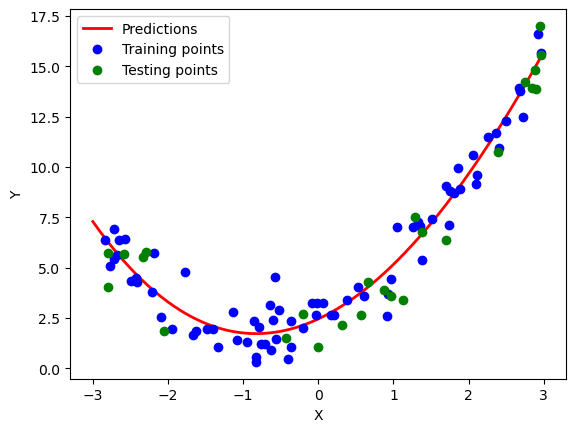

In [17]:
y_new = regression.predict(x_new_poly)
plt.plot(x_new, y_new, "r-", linewidth = 2, label = "Predictions")
plt.plot(x_train, y_train, "bo", label = "Training points")
plt.plot(x_test, y_test, "go", label = "Testing points")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

### Poloynomial Pipeline

In [40]:
from sklearn.pipeline import Pipeline

In [44]:
def poly_regression(degree):
    x_new = np.linspace(-3,3,200).reshape(200,1)

    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    model = Pipeline([
        ("poly_features", poly_features),
        ("linear_regression", LinearRegression())
    ])

    model.fit(x_train, y_train)

    # Model evaluation
    y_pred_test = model.predict(x_test)
    score3 = r2_score(y_test, y_pred_test)
    print("R2 Score:", score3)

    # plotting
    y_pred_new = model.predict(x_new)
    plt.plot(x_new, y_pred_new, "r-", linewidth=2, label="degree " + str(degree))
    plt.plot(x_train, y_train, "bo", label="Training points")
    plt.plot(x_test, y_test, "go", label="Testing points")
    plt.legend()
    plt.show()

R2 Score: 0.9460685220640132


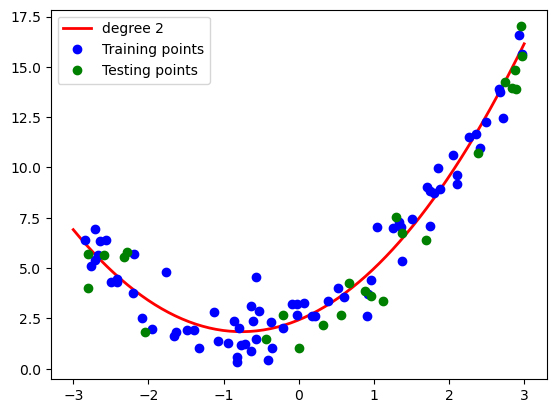

In [45]:
poly_regression(2)
